In [1]:
import pandas as pd

file_path = 'AED_building.csv'

df = pd.read_csv(file_path, sep=',', low_memory=False)

df.shape

(1518, 17)

# Feature engineering
Il s'agit de créer, transformer, ou sélectionner des variables pour améliorer la performance du modèle.

- Création de nouvelles caractéristiques (par exemple, fusionner deux colonnes pour créer une nouvelle caractéristique, ou créer des variables temporelles comme l’heure, le jour, le mois, etc.).
- Transformation des données (par exemple, normalisation, standardisation, ou logarithme pour gérer les distributions asymétriques).
- Encodage des variables catégorielles (par exemple, encodage one-hot, label encoding).
- Sélection des meilleures caractéristiques pour le modèle (par exemple, utiliser des techniques comme la sélection de caractéristiques ou l’analyse de corrélation).

In [2]:
df1 = df.copy()

### Gestion des iterations

Si iteration = 1 :
- Toutes les colonnes restent tel quel
- nombre de niveau tous les 5 pas

Si iteration = 2 :
- Regroupemet des categories test1
- nombre de niveaux tous les 5 pas

Si iteration = 3 :
- Regroupemet des categories test1
- nombre de niveaux tous les 10 pas

Si iteration = 4 :
- revoir les categories

si iteration = 5 :
- revoir les transformations oneHotEncoding et autres

si iteration = 6 :
- Avec SHARP Je revois les colonnes que je veux garder
- Je remplace les années par 2 colonnes avant 1925 et après 1925

In [3]:
iteration = 6

### Range pour les années

In [4]:
import pandas as pd
if iteration != 6 :
    # Créer des tranches de 25 ans pour la colonne YearBuilt
    bins = list(range(1900, 2026, 25))  # Crée des tranches de 1900 à 2025 avec un pas de 25 ans
    labels = [f'{start}-{start+24}' for start in bins[:-1]]  # Crée les étiquettes pour chaque tranche (ex : 1900-1924, 1925-1949, etc.)

    # Ajouter la nouvelle colonne 'YearBuiltRange' au DataFrame
    df1['YearBuiltRange'] = pd.cut(df1['YearBuilt'], bins=bins, labels=labels, right=False)

    # Insérer la colonne 'YearBuiltRange' à la 4ème place (index 3)
    df1.insert(3, 'YearBuiltRange', df1.pop('YearBuiltRange'))
    df1 = df1.drop('YearBuilt', axis=1)

    df1
if iteration in [6]:
    import numpy as np
    df1["YearBuiltRange"] = np.where(df1["YearBuilt"] < 1925, "Avant1925", "Après1925")
    df1.insert(3, 'YearBuiltRange', df1.pop('YearBuiltRange'))
    df1 = df1.drop('YearBuilt', axis=1)

### Range pour nombre de niveaux

In [5]:
if iteration in [1, 2, 3, 4, 5, 6]:
    pas = 0
    if iteration in [1, 2, 4, 5, 6]:
        pas = 5
    if iteration in [3] :
        pas = 10
    # Créer des tranches de 5 étages pour la colonne NumberofFloors (ajusté à 1-99)
    bins = list(range(1, 101, pas))  # Crée des tranches de 1 à 100 avec un pas de 10
    labels = [f'{start}-{start+4}' for start in bins[:-1]]  # Crée les étiquettes pour chaque tranche (ex : 1-5, 6-10, etc.)

    # Ajouter la nouvelle colonne 'NumberofFloorsRange' au DataFrame
    df1['NumberofFloorsRange'] = pd.cut(df1['NumberofFloors'], bins=bins, labels=labels, right=False)

    # Insérer la colonne 'NumberofFloorsRange' à la 4ème place (index 3)
    df1.insert(5, 'NumberofFloorsRange', df1.pop('NumberofFloorsRange'))
    
    df1 = df1.drop('NumberofFloors', axis=1)

    df1

### Regroupement des types de propriété en des groupes plus généraux

In [6]:
if iteration in [2, 3]:
    # Fonction mise à jour pour regrouper les catégories
    def regroup_property_type(property_type):
        if property_type in ['Hotel', 'Residence Hall', 'Low-Rise Multifamily']:
            return 'Hospitality'  # Hébergement
        elif property_type in ['University', 'K-12 School', 'Laboratory']:
            return 'Education'  # Éducation
        elif property_type in ['Medical Office', 'Hospital', 'Senior Care Community']:
            return 'Healthcare'  # Santé
        elif property_type in ['Retail Store', 'Supermarket / Grocery Store', 'Restaurant']:
            return 'Retail'  # Commerce
        elif property_type in ['Small- and Mid-Sized Office', 'Large Office', 'Worship Facility', 'Mixed Use Property']:
            return 'Office'  # Bureau
        elif property_type in ['Warehouse', 'Refrigerated Warehouse', 'Distribution Center', 'Self-Storage Facility']:
            return 'Storage & Logistics'  # Stockage et Logistique
        else:
            return 'Other'  # Autres

    # Application de la fonction au DataFrame
    df1['GeneralPropertyType'] = df1['PrimaryPropertyType'].apply(regroup_property_type)

    # Vérification des nouvelles catégories
    print(df1['GeneralPropertyType'].value_counts())

if iteration in [4]:
    # Fonction mise à jour pour regrouper les catégories
    def regroup_property_type(property_type):
        if property_type in ['Hotel', 'Residence Hall', 'Low-Rise Multifamily']:
            return 'Hospitality'  # Hébergement
        elif property_type in ['University', 'K-12 School', 'Laboratory']:
            return 'Education'  # Éducation
        elif property_type in ['Medical Office', 'Hospital', 'Senior Care Community']:
            return 'Healthcare'  # Santé
        elif property_type in ['Retail Store', 'Supermarket / Grocery Store', 'Restaurant']:
            return 'Retail'  # Commerce
        elif property_type in ['Small- and Mid-Sized Office']:
            return 'Small- and Mid-Sized Office'
        elif property_type in ['Large Office']:
            return 'Large Office'
        elif property_type in ['Worship Facility']:
            return 'Worship Facility'
        elif property_type in ['Mixed Use Property']:
            return 'Mixed Use Property'
        elif property_type in ['Warehouse']:
            return 'Warehouse'  # Stockage et Logistique
        elif property_type in ['Refrigerated Warehouse', 'Distribution Center', 'Self-Storage Facility']:
            return 'Storage & Logistics'  # Stockage et Logistique
        else:
            return 'Other'  # Autres

    # Application de la fonction au DataFrame
    df1['GeneralPropertyType'] = df1['PrimaryPropertyType'].apply(regroup_property_type)

    # Vérification des nouvelles catégories
    print(df1['GeneralPropertyType'].value_counts())

In [7]:
if iteration in [2, 3, 4]:
    import matplotlib.pyplot as plt
    import seaborn as sns

    # Création d'une table croisée (pivot table) pour compter les occurrences
    pivot_table = df1.pivot_table(
        index='GeneralPropertyType',
        columns='PrimaryPropertyType',
        aggfunc='size',
        fill_value=0
    )

    # Visualisation sous forme de heatmap
    plt.figure(figsize=(12, 8))
    sns.heatmap(pivot_table, annot=True, fmt="d", cmap="Blues")
    plt.title("Répartition des PrimaryPropertyType dans chaque GeneralPropertyType")
    plt.xlabel("PrimaryPropertyType")
    plt.ylabel("GeneralPropertyType")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    # Optionnel : Visualisation en diagramme à barres empilées
    pivot_table.T.plot(kind='bar', stacked=True, figsize=(14, 8))
    plt.title("Répartition des PrimaryPropertyType dans chaque GeneralPropertyType")
    plt.xlabel("PrimaryPropertyType")
    plt.ylabel("Count")
    plt.legend(title="GeneralPropertyType", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

In [8]:
if iteration in [2, 3, 4]:
    # Remplacement de la colonne PrimaryPropertyType par GeneralPropertyType
    df1.insert(1, 'GeneralPropertyType', df1.pop('GeneralPropertyType'))

    # Suppression de la colonne PrimaryPropertyType
    df1 = df1.drop(columns=['PrimaryPropertyType'])

### ProportionParking & ProportionBuilding

In [9]:
# Calcul des taux en divisant par PropertyGFATotal
df1['ProportionParking'] = df1['PropertyGFAParking'] / df1["PropertyGFATotal"]
df1['ProportionBuilding'] = df1["PropertyGFABuilding(s)"] / df1["PropertyGFATotal"]
df1

,OSEBuildingID,PrimaryPropertyType,Neighborhood,YearBuiltRange,NumberofBuildings,NumberofFloorsRange,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseTypeGFA,ENERGYSTARScore,SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kBtu),NaturalGas(kBtu),TotalGHGEmissions,GHGEmissionsIntensity,ProportionParking,ProportionBuilding
0,1,Hotel,DOWNTOWN,Après1925,1,11-15,88434,0,88434,88434.0,60.0,7.456910e+06,2003882.00,3.946027e+06,1.276453e+06,249.98,2.83,0.000000,1.000000
1,2,Hotel,DOWNTOWN,Après1925,1,11-15,103566,15064,88502,83880.0,61.0,8.664479e+06,0.00,3.242851e+06,5.145082e+06,295.86,2.86,0.145453,0.854547
2,5,Hotel,DOWNTOWN,Après1925,1,6-10,61320,0,61320,61320.0,56.0,6.946800e+06,2214446.25,2.768924e+06,1.811213e+06,286.43,4.67,0.000000,1.000000
3,8,Hotel,DOWNTOWN,Après1925,1,16-20,175580,62000,113580,123445.0,75.0,1.465650e+07,0.00,5.368607e+06,8.803998e+06,505.01,2.88,0.353115,0.646885
4,9,Other,DOWNTOWN,Après1925,1,1-5,97288,37198,60090,88830.0,NaN,1.258171e+07,0.00,7.371434e+06,4.715182e+06,301.81,3.10,0.382349,0.617651
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1513,50221,Other,DELRIDGE NEIGHBORHOODS,Après1925,1,1-5,18261,0,18261,18261.0,NaN,1.025432e+06,0.00,6.323620e+05,2.997200e+05,20.33,1.11,0.000000,1.000000
1514,50223,Other,DOWNTOWN,Après1925,1,1-5,16000,0,16000,16000.0,NaN,1.053706e+06,0.00,3.965461e+05,5.537300e+05,32.17,2.01,0.000000,1.000000
1515,50224,Other,MAGNOLIA / QUEEN ANNE,Après1925,1,1-5,13157,0,13157,7583.0,NaN,6.053764e+06,0.00,1.792159e+06,3.973739e+06,223.54,16.99,0.000000,1.000000
1516,50225,Mixed Use Property,GREATER DUWAMISH,Après1925,1,1-5,14101,0,14101,6601.0,NaN,7.828413e+05,0.00,3.488702e+05,3.706010e+05,22.11,1.57,0.000000,1.000000


### Création des proportions d'énergie

In [10]:
# Calcul des taux en divisant par PropertyGFATotal
df1['ProportionOfSteamUse'] = df1['SteamUse(kBtu)'] / df1["SiteEnergyUseWN(kBtu)"]
df1['ProportionOfElectricity'] = df1['Electricity(kBtu)'] / df1["SiteEnergyUseWN(kBtu)"]
df1['ProportionOfNaturalGas'] = df1['NaturalGas(kBtu)'] / df1["SiteEnergyUseWN(kBtu)"]


# Insérer ces nouvelles colonnes aux positions 12, 13, 14
df1.insert(12, 'ProportionOfSteamUse', df1.pop('ProportionOfSteamUse'))
df1.insert(13, 'ProportionOfElectricity', df1.pop('ProportionOfElectricity'))
df1.insert(14, 'ProportionOfNaturalGas', df1.pop('ProportionOfNaturalGas'))

df1 = df1.drop(["SteamUse(kBtu)","Electricity(kBtu)","NaturalGas(kBtu)","TotalGHGEmissions", "SiteEnergyUseWN(kBtu)"], axis=1)

# Extraire la colonne 'SiteEnergyUseWN(kBtu)' et la mettre à l'avant-dernière position
df1.insert(len(df1.columns) - 1, 'GHGEmissionsIntensity', df1.pop('GHGEmissionsIntensity'))
df1

,OSEBuildingID,PrimaryPropertyType,Neighborhood,YearBuiltRange,NumberofBuildings,NumberofFloorsRange,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseTypeGFA,ENERGYSTARScore,ProportionOfSteamUse,ProportionOfElectricity,ProportionOfNaturalGas,ProportionParking,ProportionBuilding,GHGEmissionsIntensity
0,1,Hotel,DOWNTOWN,Après1925,1,11-15,88434,0,88434,88434.0,60.0,0.268728,0.529177,0.171177,0.000000,1.000000,2.83
1,2,Hotel,DOWNTOWN,Après1925,1,11-15,103566,15064,88502,83880.0,61.0,0.000000,0.374270,0.593813,0.145453,0.854547,2.86
2,5,Hotel,DOWNTOWN,Après1925,1,6-10,61320,0,61320,61320.0,56.0,0.318772,0.398590,0.260726,0.000000,1.000000,4.67
3,8,Hotel,DOWNTOWN,Après1925,1,16-20,175580,62000,113580,123445.0,75.0,0.000000,0.366295,0.600689,0.353115,0.646885,2.88
4,9,Other,DOWNTOWN,Après1925,1,1-5,97288,37198,60090,88830.0,NaN,0.000000,0.585885,0.374765,0.382349,0.617651,3.10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1513,50221,Other,DELRIDGE NEIGHBORHOODS,Après1925,1,1-5,18261,0,18261,18261.0,NaN,0.000000,0.616679,0.292287,0.000000,1.000000,1.11
1514,50223,Other,DOWNTOWN,Après1925,1,1-5,16000,0,16000,16000.0,NaN,0.000000,0.376335,0.525507,0.000000,1.000000,2.01
1515,50224,Other,MAGNOLIA / QUEEN ANNE,Après1925,1,1-5,13157,0,13157,7583.0,NaN,0.000000,0.296040,0.656408,0.000000,1.000000,16.99
1516,50225,Mixed Use Property,GREATER DUWAMISH,Après1925,1,1-5,14101,0,14101,6601.0,NaN,0.000000,0.445646,0.473405,0.000000,1.000000,1.57


## Vérification des corrélation avec les nouvelles variables crées
Je m'assure ensuite que les nouvelles colonnes crées ne sont pas fortement correlées entre elles.

C:\Users\danie\AppData\Local\Temp\ipykernel_8108\2058192021.py:6: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr_matrix = df1.corr()


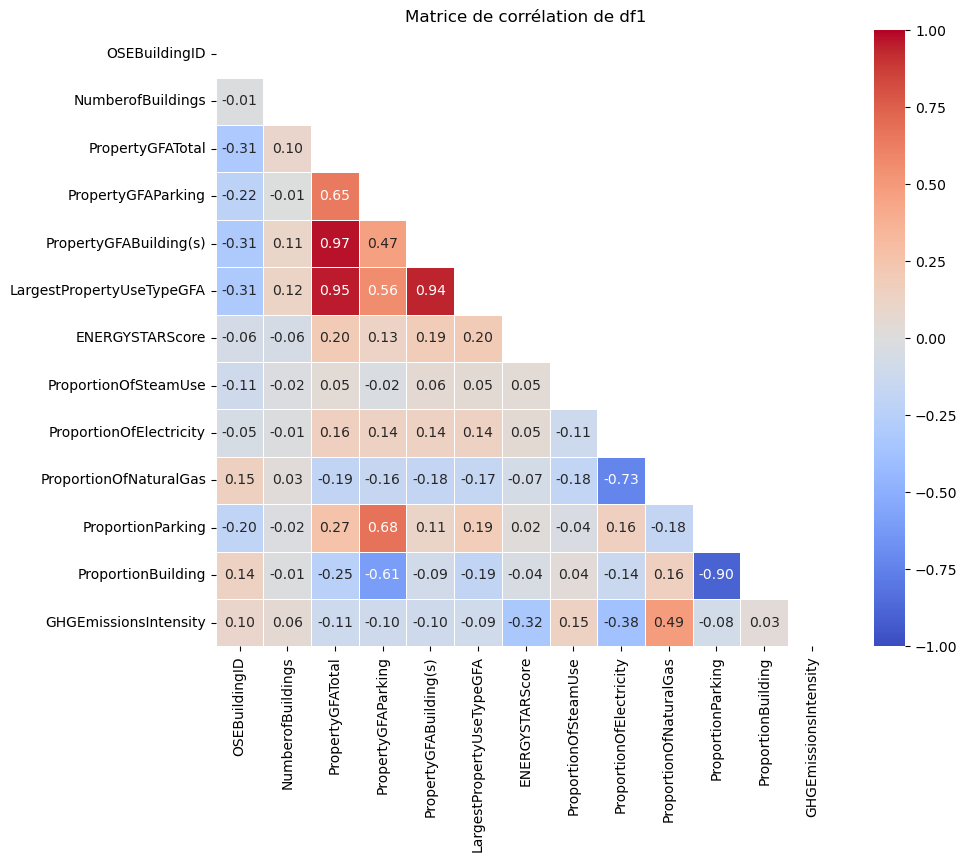

In [11]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Calcul de la matrice de corrélation
corr_matrix = df1.corr()

# Masquer la partie supérieure de la matrice de corrélation (triangle supérieur)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Affichage de la matrice de corrélation avec un heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', mask=mask, vmin=-1, vmax=1, fmt=".2f", linewidths=0.5)
plt.title("Matrice de corrélation de df1")
plt.show()

In [12]:
# Lorsque je les supprime j'obtiens un score moins bon avec mes modèles
#df1 = df1.drop(["PropertyGFABuilding(s)", "LargestPropertyUseTypeGFA"], axis=1)

### Categories encoding & entrainement du modèle

In [13]:
from sklearn.preprocessing import LabelEncoder
    
if iteration in [1, 2, 3, 4, 6]:
    # One hot encoding
    df1 = pd.get_dummies(df1, columns=['YearBuiltRange'], drop_first=False)
if iteration in [5]:
    # Initialiser le label encoder
    label_encoder = LabelEncoder()

    # Appliquer le label encoding sur la colonne 'YearBuiltRange'
    df1['YearBuiltRange'] = label_encoder.fit_transform(df1['YearBuiltRange'])

In [14]:
if iteration in [1, 2, 3, 4, 6]:
    # One hot encoding
    df1 = pd.get_dummies(df1, columns=['Neighborhood'], drop_first=False)
if iteration in [5]:
    # Initialiser le label encoder
    label_encoder = LabelEncoder()

    # Appliquer le label encoding sur la colonne 'YearBuiltRange'
    df1['Neighborhood'] = label_encoder.fit_transform(df1['Neighborhood'])

In [15]:
if iteration in [2, 3, 4]:
    df1 = pd.get_dummies(df1, columns=['GeneralPropertyType'], drop_first=False)
if iteration in [1, 6] :
    df1 = pd.get_dummies(df1, columns=['PrimaryPropertyType'], drop_first=False)
if iteration in [5]:
    # Initialiser le label encoder
    label_encoder = LabelEncoder()

    # Appliquer le label encoding sur la colonne 'YearBuiltRange'
    df1['PrimaryPropertyType'] = label_encoder.fit_transform(df1['PrimaryPropertyType'])

In [16]:
# Label encoding
from sklearn.preprocessing import LabelEncoder

# Créer une instance de LabelEncoder
label_encoder = LabelEncoder()

# Appliquer le Label Encoding à la colonne 'NumberofFloorsRange'
df1['NumberofFloorsRange_encoded'] = label_encoder.fit_transform(df1['NumberofFloorsRange']) + 1  # Ajout de 1 pour que la première catégorie soit 1

df1 = df1.drop(["NumberofFloorsRange"], axis=1)

In [17]:
df1.iloc[:, 0:20]

,OSEBuildingID,NumberofBuildings,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseTypeGFA,ENERGYSTARScore,ProportionOfSteamUse,ProportionOfElectricity,ProportionOfNaturalGas,ProportionParking,ProportionBuilding,GHGEmissionsIntensity,YearBuiltRange_Après1925,YearBuiltRange_Avant1925,Neighborhood_BALLARD,Neighborhood_CENTRAL,Neighborhood_DELRIDGE,Neighborhood_DELRIDGE NEIGHBORHOODS,Neighborhood_DOWNTOWN
0,1,1,88434,0,88434,88434.0,60.0,0.268728,0.529177,0.171177,0.000000,1.000000,2.83,1,0,0,0,0,0,1
1,2,1,103566,15064,88502,83880.0,61.0,0.000000,0.374270,0.593813,0.145453,0.854547,2.86,1,0,0,0,0,0,1
2,5,1,61320,0,61320,61320.0,56.0,0.318772,0.398590,0.260726,0.000000,1.000000,4.67,1,0,0,0,0,0,1
3,8,1,175580,62000,113580,123445.0,75.0,0.000000,0.366295,0.600689,0.353115,0.646885,2.88,1,0,0,0,0,0,1
4,9,1,97288,37198,60090,88830.0,NaN,0.000000,0.585885,0.374765,0.382349,0.617651,3.10,1,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1513,50221,1,18261,0,18261,18261.0,NaN,0.000000,0.616679,0.292287,0.000000,1.000000,1.11,1,0,0,0,0,1,0
1514,50223,1,16000,0,16000,16000.0,NaN,0.000000,0.376335,0.525507,0.000000,1.000000,2.01,1,0,0,0,0,0,1
1515,50224,1,13157,0,13157,7583.0,NaN,0.000000,0.296040,0.656408,0.000000,1.000000,16.99,1,0,0,0,0,0,0
1516,50225,1,14101,0,14101,6601.0,NaN,0.000000,0.445646,0.473405,0.000000,1.000000,1.57,1,0,0,0,0,0,0


In [18]:
df1 = df1.drop(["OSEBuildingID"], axis=1)

In [19]:
df2 = df1.copy()
df1 = df1.drop(columns=['ENERGYSTARScore'])
df1.shape

(1518, 49)

In [20]:
import warnings
warnings.filterwarnings("ignore")
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1518 entries, 0 to 1517
Data columns (total 49 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   NumberofBuildings                                1518 non-null   int64  
 1   PropertyGFATotal                                 1518 non-null   int64  
 2   PropertyGFAParking                               1518 non-null   int64  
 3   PropertyGFABuilding(s)                           1518 non-null   int64  
 4   LargestPropertyUseTypeGFA                        1518 non-null   float64
 5   ProportionOfSteamUse                             1518 non-null   float64
 6   ProportionOfElectricity                          1518 non-null   float64
 7   ProportionOfNaturalGas                           1518 non-null   float64
 8   ProportionParking                                1518 non-null   float64
 9   ProportionBuilding            

## Dummy Regressor
modèle basic qui utilise la moyenne pour prédire la variable cible

In [21]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyRegressor
from sklearn.metrics import r2_score
import numpy as np
import pandas as pd

def preprocess_data(df, log_transform=False, standardize=False):
    """
    Prépare les données avec options de transformation logarithmique et de standardisation.
    
    :param df: DataFrame contenant les données
    :param log_transform: Booléen, appliquer ou non la transformation logarithmique sur y
    :param standardize: Booléen, appliquer ou non la standardisation sur X
    :return: X_train, X_test, y_train, y_test
    """
    # Séparation des variables explicatives et cible
    X = df.drop(columns=['GHGEmissionsIntensity'])
    y = df['GHGEmissionsIntensity']
    
    # Transformation logarithmique de la cible si demandé
    if log_transform:
        y = np.log1p(y)
        print("Transformation logarithmique de Y appliquée.")
    else:
        print("Pas de transformation logarithmique de Y.")
    
    # Séparation en ensembles d'entraînement et de test
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Standardisation si demandé
    if standardize:
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        
        X_train = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
        X_test = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)
        print("Standardisation appliquée.")
    else:
        print("Pas de standardisation des colonnes explicatives.")
    
    return X_train, X_test, y_train, y_test

def evaluate_dummy_regressor(X_train, y_train):
    """
    Évalue un DummyRegressor avec validation croisée (5-fold) en utilisant le R² score.
    
    :param X_train: Variables explicatives d'entraînement
    :param y_train: Variable cible d'entraînement
    :return: Score moyen du R²
    """
    dummy_regressor = DummyRegressor(strategy="mean")
    scores = cross_val_score(dummy_regressor, X_train, y_train, cv=5, scoring='r2')
    print(f"Score R² moyen : {np.mean(scores):.4f}")
    
    return scores

In [22]:
# Exemple d'utilisation avec un DataFrame df1
X_train, X_test, y_train, y_test = preprocess_data(df1, log_transform=True, standardize=True)
evaluate_dummy_regressor(X_train, y_train)

Transformation logarithmique de Y appliquée.
Standardisation appliquée.
Score R² moyen : -0.0088


array([-0.00753892, -0.00721537, -0.00853454, -0.00106582, -0.01965861])

## Ridge
Un peu mieux que le précédent, ce modèle utilise le paramètre alpha pour pénaliser certaines variables.
Contrairement à Lasso, toutes les variables resteront dans le modèle, mais leur poids sera juste réduit grace à alpha


Alpha faible = Moins de pénalisation → Le modèle peut être plus complexe, mais risque de surajuster (overfitting).
Alpha élevé = Plus de pénalisation → Le modèle est plus simple, moins flexible, mais risque de sous-ajuster (underfitting).

Plus alpha est grand, plus les coefficients des variables seront réduits, mais aucune variable n'est supprimée.

In [23]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

def preprocess_data(df, log_transform=False, standardize=False):
    X = df.drop(columns=['GHGEmissionsIntensity'])
    y = df['GHGEmissionsIntensity']
    
    if log_transform:
        y = np.log1p(y)  # Transformation logarithmique de Y
        print("Transformation logarithmique de Y appliquée.")
    else:
        print("Pas de transformation logarithmique de Y.")
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    if standardize:
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        
        X_train = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
        X_test = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)
        print("Standardisation appliquée.")
    else:
        print("Pas de standardisation des colonnes explicatives.")
    
    return X_train, X_test, y_train, y_test

In [24]:
def ridge_regression(X_train, X_test, y_train, y_test, log_transform, alphas=[0.001, 0.01, 0.1, 1.0, 10.0, 100.0]):
    param_grid = {'alpha': alphas}
    ridge = Ridge()
    
    # GridSearchCV choisit le meilleur alpha en validation croisée
    grid_search = GridSearchCV(ridge, param_grid, cv=5, scoring='r2')
    grid_search.fit(X_train, y_train)
    
    # On récupère le meilleur modèle trouvé par la validation croisée
    best_model = grid_search.best_estimator_
    best_alpha = grid_search.best_params_['alpha']
    best_r2_cv = grid_search.best_score_  # Score moyen sur CV
    
    # Évaluation sur le jeu de test (uniquement après avoir fixé le modèle final)
    y_pred = best_model.predict(X_test)
    
    if log_transform:
        y_pred = np.expm1(y_pred)
        y_test = np.expm1(y_test)
    
    test_r2 = r2_score(y_test, y_pred)

    print(f"Meilleur alpha trouvé (via CV) : {best_alpha}")
    print(f"Score R² moyen avec validation croisée : {best_r2_cv:.4f}")
    print(f"Score R² final sur le jeu de test : {test_r2:.4f}")
    
    return best_model, best_alpha, best_r2_cv, test_r2

In [25]:
X_train, X_test, y_train, y_test = preprocess_data(df1, log_transform=True, standardize=True)
model, best_alpha, best_r2_cv, test_r2 = ridge_regression(X_train, X_test, y_train, y_test, log_transform=True)

Transformation logarithmique de Y appliquée.
Standardisation appliquée.
Meilleur alpha trouvé (via CV) : 10.0
Score R² moyen avec validation croisée : 0.6822
Score R² final sur le jeu de test : 0.4564


## ElasticNet

Ridge (alpha) : Réduit l'impact des variables, mais toutes restent dans le modèle.

Lasso (alpha) : Réduit l'impact des variables, mais certaines peuvent être supprimées complètement.


Le L1 ratio dans ElasticNet permet de contrôler combien de L1 (Lasso) et de L2 (Ridge) tu veux dans ton modèle :

- Si L1 ratio = 1.0 : Tu as 100% de Lasso (pénalisation L1), donc le modèle va potentiellement éliminer des variables et en garder seulement les plus pertinentes.

- Si L1 ratio = 0.0 : Tu as 100% de Ridge (pénalisation L2), donc toutes les variables resteront dans le modèle, mais leur poids sera juste réduit.

- Si L1 ratio entre 0.0 et 1.0 : Tu obtiens un compromis entre les deux. Le modèle fait un peu de réduction de poids (L2) tout en ayant aussi la possibilité de supprimer des variables (L1).

In [26]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNet
from sklearn.metrics import r2_score

def preprocess_data(df, log_transform=True, standardize=True):
    X = df.drop(columns=['GHGEmissionsIntensity'])
    y = df['GHGEmissionsIntensity']
    
    if log_transform:
        y = np.log1p(y)
        print("Transformation logarithmique de Y appliquée.")
    else:
        print("Pas de transformation logarithmique de Y.")
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    if standardize:
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        
        X_train = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
        X_test = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)
        print("Standardisation appliquée.")
    else:
        print("Pas de standardisation des colonnes explicatives.")
    
    return X_train, X_test, y_train, y_test

In [27]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import GridSearchCV
import numpy as np

def elasticnet_regression(X_train, y_train, X_test, y_test, log_transform, alphas=[0.001, 0.01, 0.1, 1.0, 10.0, 100.0], l1_ratios=[0.1, 0.5, 0.9]):
    param_grid = {'alpha': alphas, 'l1_ratio': l1_ratios}
    elasticnet = ElasticNet()
    grid_search = GridSearchCV(elasticnet, param_grid, cv=5, scoring='r2')
    grid_search.fit(X_train, y_train)
    
    # Meilleur modèle basé sur la recherche de grille
    best_model = grid_search.best_estimator_

    # Validation croisée pour obtenir le meilleur R²
    best_r2_cv = grid_search.best_score_
    
    # Prédictions sur le jeu de test
    y_pred = best_model.predict(X_test)

    # Reconversion si transformation logarithmique
    if log_transform:
        y_test = np.expm1(y_test)
        y_pred = np.expm1(y_pred)
    
    # Calcul des métriques
    test_r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)

    best_alpha = grid_search.best_params_['alpha']
    best_l1_ratio = grid_search.best_params_['l1_ratio']
    
    print(f"Meilleur alpha trouvé : {best_alpha:.4f}")
    print(f"Meilleur l1_ratio trouvé : {best_l1_ratio:.4f}")
    print(f"Score R² moyen avec validation croisée : {best_r2_cv:.4f}")
    print(f"Score R² sur le jeu de test : {test_r2:.4f}")
    print(f"RMSE sur le jeu de test : {rmse:.4f}")
    print(f"MAE sur le jeu de test : {mae:.4f}")

    
    return best_model, best_alpha, best_l1_ratio, best_r2_cv, test_r2, rmse, mae

# Séparation des données
X_train, X_test, y_train, y_test = preprocess_data(df1, log_transform=True, standardize=True)

# Utilisation de GridSearchCV pour la recherche des meilleurs hyperparamètres sur X_train et y_train
model, best_alpha, best_l1_ratio, best_r2_cv, test_r2, rmse, mae = elasticnet_regression(
    X_train, y_train, X_test, y_test, log_transform=True
)

Transformation logarithmique de Y appliquée.
Standardisation appliquée.
Meilleur alpha trouvé : 0.0100
Meilleur l1_ratio trouvé : 0.1000
Score R² moyen avec validation croisée : 0.6829
Score R² sur le jeu de test : 0.4537
RMSE sur le jeu de test : 1.6190
MAE sur le jeu de test : 0.7878


## Modèles plus performants

### Décision Tree

In [71]:
df1 = df3.copy()

In [72]:
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.tree import DecisionTreeRegressor
import numpy as np
import pandas as pd
import time

logarithmiqueTrans = True
standardize = True 

# Séparation des variables explicatives et cible
X = df1.drop(columns=['GHGEmissionsIntensity'])
y = df1['GHGEmissionsIntensity']

# Transformation logarithmique de la cible si activée
y_log = np.log1p(y) if logarithmiqueTrans else y

# Séparation en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y_log, test_size=0.2, random_state=42)

# Standardisation des variables explicatives si activée
if standardize:
    scaler = StandardScaler()
    X_train_processed1 = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
    X_test_processed1 = pd.DataFrame(scaler.transform(X_test), columns=X.columns)
else:
    X_train_processed1 = X_train.copy()
    X_test_processed1 = X_test.copy()

# Initialisation du modèle DecisionTreeRegressor
dt_model = DecisionTreeRegressor(random_state=42)

# Grille des hyperparamètres pour la validation croisée
param_grid = {
    'max_depth': [3, 5, 7, 10],  # Profondeur maximale des arbres
    'min_samples_split': [2, 5, 10],  # Nombre minimum d'échantillons nécessaires pour diviser un noeud
    'min_samples_leaf': [1, 2, 4],    # Nombre minimum d'échantillons dans une feuille
    'max_features': ['sqrt', 'log2'],  # Nombre de features à considérer pour chaque split
    'splitter': ['best', 'random']   # Critère de division des noeuds
}

Temps d'entraînement (fit) : 1.1724 secondes
Temps de prédiction : 0.0020 secondes
Meilleurs hyperparamètres : {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 10, 'splitter': 'random'}
Mesures sur l'ensemble de test :
R² : 0.2781
RMSE : 1.2838
MAE : 0.7206

Scores moyens pour chaque mesure dans la validation croisée :
neg_mean_squared_error: -0.1796
r2: 0.2959
neg_mean_absolute_error: -0.3175


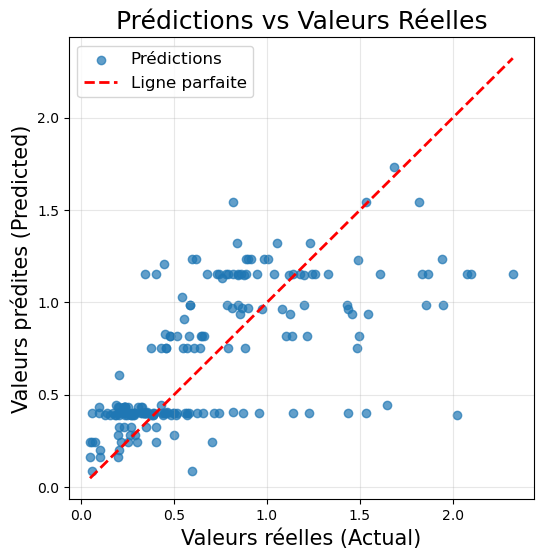

In [73]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score
import time
import numpy as np

# Fonction pour entraîner et évaluer le modèle
def train_and_evaluate(X_train, X_test, y_train, y_test, transformation):
    # Ajouter plusieurs mesures de scoring
    scoring = ['neg_mean_squared_error', 'r2', 'neg_mean_absolute_error']
    
    # Démarrer le chronométrage pour l'entraînement
    start_time = time.time()
    
    # Effectuer une validation croisée avec GridSearchCV
    grid_search = GridSearchCV(
        estimator=dt_model,
        param_grid=param_grid,
        cv=5,  # Validation croisée sur 5 splits
        scoring=scoring,
        refit='r2',  # Choisir la meilleure méthode de scoring pour refit
        n_jobs=-1  # Utiliser tous les cœurs disponibles
    )
    
    # Entraînement du modèle
    grid_search.fit(X_train, y_train)
    
    # Chronométrer la durée d'entraînement
    fit_time = time.time() - start_time
    print(f"Temps d'entraînement (fit) : {fit_time:.4f} secondes")
    
    # Meilleur modèle après recherche d'hyperparamètres
    best_model = grid_search.best_estimator_
    
    # Prédictions sur l'ensemble de test
    start_time_predict = time.time()
    y_pred = best_model.predict(X_test)
    
    # Chronométrer la durée de la prédiction
    predict_time = time.time() - start_time_predict
    print(f"Temps de prédiction : {predict_time:.4f} secondes")
    
    # Si on a fait une transformation logarithmique, inversez-la
    if logarithmiqueTrans:
        y_test = np.expm1(y_test)
        y_pred = np.expm1(y_pred)    
    
    # Calcul des métriques : R², RMSE, MAE
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    
    # Affichage des résultats
    print(f"Meilleurs hyperparamètres : {grid_search.best_params_}")
    print("Mesures sur l'ensemble de test :")
    print(f"R² : {r2:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"MAE : {mae:.4f}")
    
    # Récupérer les résultats du GridSearchCV
    results = grid_search.cv_results_
    
    # Extraire les scores moyens pour chaque métrique
    print("\nScores moyens pour chaque mesure dans la validation croisée :")
    for metric in scoring:
        print(f"{metric}: {np.mean(results[f'mean_test_{metric}']):.4f}")
    
    return best_model, scaler if standardize else None  # Retourner le modèle et le scaler (si standardisé)

# Appeler la fonction pour entraîner et évaluer
best_model1, scaler = train_and_evaluate(
    X_train_processed1, 
    X_test_processed1, 
    y_train, 
    y_test, 
    "Standardisation" if standardize else "Sans Standardisation",
)

import matplotlib.pyplot as plt

# Obtention des prédictions
y_pred = best_model1.predict(X_test_processed1)

# Évaluation du modèle
plt.figure(figsize=(6, 6))  # Taille du graphique
plt.scatter(y_test, y_pred, alpha=0.7, label="Prédictions")  # Points scatter pour 'réel vs prédit'
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         color='red', linestyle='--', linewidth=2, label="Ligne parfaite")  # Ligne diagonale idéale

# Labels et légende
plt.xlabel("Valeurs réelles (Actual)", fontsize=15)
plt.ylabel("Valeurs prédites (Predicted)", fontsize=15)
plt.title("Prédictions vs Valeurs Réelles", fontsize=18)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.show()

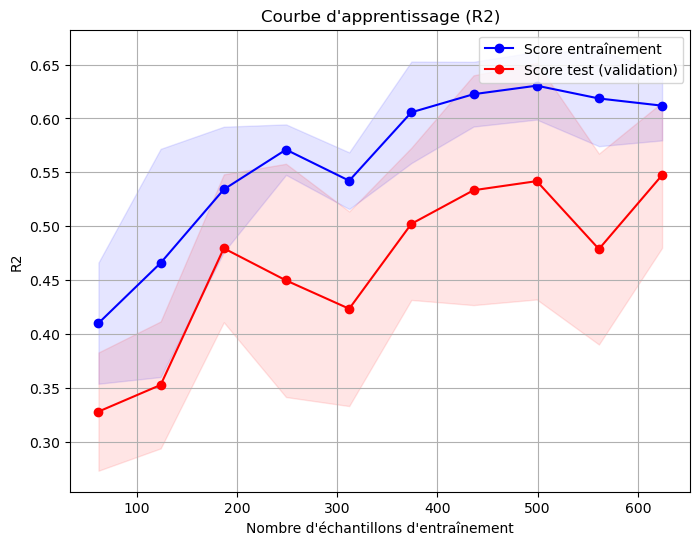

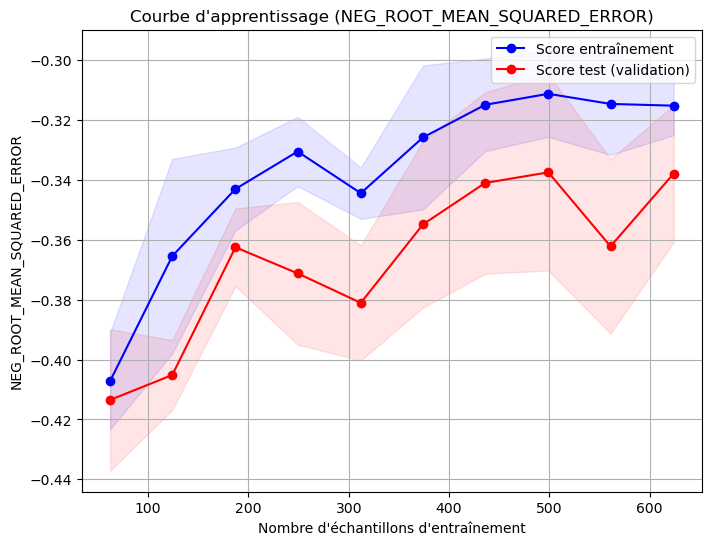

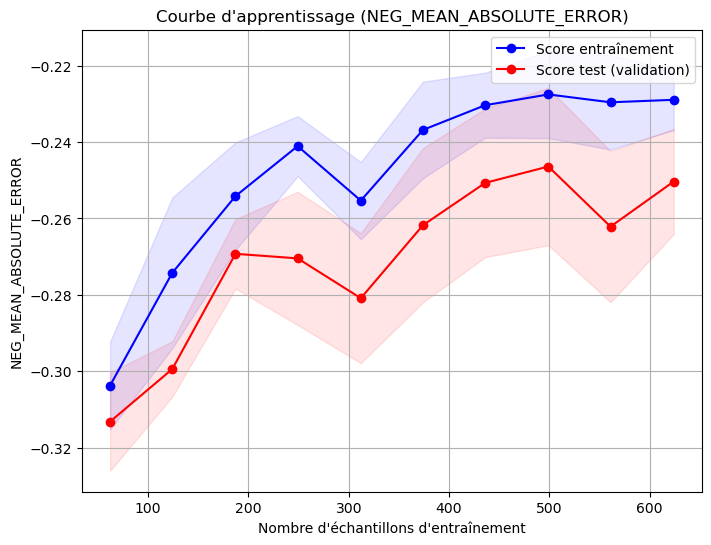

In [74]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

# Fonction pour tracer les courbes d'apprentissage
def plot_learning_curve(model, X, y, cv=5, scoring="r2"):
    train_sizes, train_scores, test_scores = learning_curve(
        model, X, y, cv=cv, scoring=scoring, n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 10)
    )
    
    # Moyenne et écart-type des scores
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)

    # Tracé des courbes d'apprentissage
    plt.figure(figsize=(8, 6))
    plt.plot(train_sizes, train_mean, 'o-', color="blue", label="Score entraînement")
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="blue")

    plt.plot(train_sizes, test_mean, 'o-', color="red", label="Score test (validation)")
    plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color="red")

    plt.xlabel("Nombre d'échantillons d'entraînement")
    plt.ylabel(scoring.upper())
    plt.title(f"Courbe d'apprentissage ({scoring.upper()})")
    plt.legend()
    plt.grid()
    plt.show()

# Tracer les courbes d'apprentissage pour R²
plot_learning_curve(best_model1, X_train_processed1, y_train, scoring="r2")

# Optionnel : Tracer les courbes pour RMSE
plot_learning_curve(best_model1, X_train_processed1, y_train, scoring="neg_root_mean_squared_error")

# Optionnel : Tracer les courbes pour MAE
plot_learning_curve(best_model1, X_train_processed1, y_train, scoring="neg_mean_absolute_error")

### Gradiant Boosting

In [62]:
df1 = df3.copy()

In [63]:
# !pip install shap

In [75]:
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import GradientBoostingRegressor
import numpy as np
import pandas as pd
import time

logarithmiqueTrans = True
standardize = True 

# Séparation des variables explicatives et cible
X = df1.drop(columns=['GHGEmissionsIntensity'])
y = df1['GHGEmissionsIntensity']

# Transformation logarithmique de la variable cible si activée
y_log = np.log1p(y) if logarithmiqueTrans else y

# Séparation en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y_log, test_size=0.2, random_state=42)

# Standardisation des variables explicatives si activée
if standardize:
    scaler = StandardScaler()
    X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
    X_test = pd.DataFrame(scaler.transform(X_test), columns=X.columns)

# Initialisation du modèle Gradient Boosting
gb_model = GradientBoostingRegressor(random_state=42)

# Définir la grille des hyperparamètres pour la validation croisée
param_grid = {
    'n_estimators': [25, 50, 100],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7, 10, 20],
    'subsample': [0.8]
}

In [76]:
def train_and_evaluate(X_train, X_test, y_train, y_test, transformation):
    print(f"\nEntraînement {transformation} :")
    
    # Ajouter plusieurs mesures de scoring, y compris R² et RMSE
    scoring = {
        'RMSE': 'neg_mean_squared_error',
        'R2': 'r2',
        'MAE': 'neg_mean_absolute_error'
    }
    
    # Démarrer le chronométrage pour l'entraînement (fit)
    start_time = time.time()
    
    # Effectuer une validation croisée avec GridSearchCV pour trouver les meilleurs hyperparamètres
    grid_search = GridSearchCV(
        estimator=gb_model,
        param_grid=param_grid,
        cv=5,  # Validation croisée sur 5 splits
        scoring=scoring,
        refit='R2',  # Choisir la meilleure méthode de scoring pour refit
        n_jobs=-1
    )
    
    grid_search.fit(X_train, y_train)
    
    # Chronométrer la durée d'entraînement
    fit_time = time.time() - start_time
    print(f"Temps d'entraînement (fit) : {fit_time:.4f} secondes")
    
    # Le meilleur modèle après recherche d'hyperparamètres
    best_model = grid_search.best_estimator_
    
    # Prédictions sur l'ensemble de test
    start_time_predict = time.time()
    y_pred = best_model.predict(X_test)
    
    # Chronométrer la durée de la prédiction
    predict_time = time.time() - start_time_predict
    print(f"Temps de prédiction : {predict_time:.4f} secondes")
    
    # Si on a fait une transformation logarithmique, inversez-la
    if logarithmiqueTrans:
        y_test = np.expm1(y_test)
        y_pred = np.expm1(y_pred)
    
    # Calcul des métriques : R², RMSE, MAE
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    
    print(f"Meilleurs hyperparamètres : {grid_search.best_params_}")
    print("\nMesure sur test")
    print(f"R2 : {r2:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"MAE : {mae:.4f}")
    
    # Récupérer les résultats du GridSearchCV
    results = grid_search.cv_results_
        
    # Afficher les scores moyens pour chaque mesure dans la validation croisée
    print("\nScores moyens pour chaque mesure dans la validation croisée :")
    mean_r2_scores = np.mean(results['mean_test_R2'])
    mean_rmse_scores = np.mean(-results['mean_test_RMSE'])  # RMSE est négatif dans 'neg_mean_squared_error'
    mean_mae_scores = np.mean(-results['mean_test_MAE'])  # MAE est également négatif dans 'neg_mean_absolute_error'

    print(f"Moyenne des scores R² : {mean_r2_scores:.4f}")
    print(f"Moyenne des scores RMSE : {mean_rmse_scores:.4f}")
    print(f"Moyenne des scores MAE : {mean_mae_scores:.4f}")
    
    return best_model

In [77]:
# Appeler la fonction pour entraîner et évaluer
best_model = train_and_evaluate(
    X_train, 
    X_test, 
    y_train, 
    y_test, 
    "Standardisation" if standardize else "Sans Standardisation"
)


Entraînement Standardisation :
Temps d'entraînement (fit) : 35.0201 secondes
Temps de prédiction : 0.0041 secondes
Meilleurs hyperparamètres : {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}

Mesure sur test
R2 : 0.7213
RMSE : 0.7977
MAE : 0.4503

Scores moyens pour chaque mesure dans la validation croisée :
Moyenne des scores R² : 0.6062
Moyenne des scores RMSE : 0.0994
Moyenne des scores MAE : 0.2262


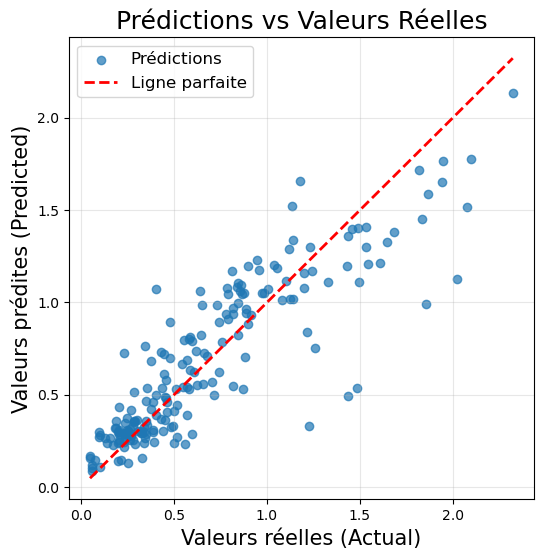

In [67]:
import matplotlib.pyplot as plt

# Obtention des prédictions
y_pred = best_model.predict(X_test)

# Évaluation du modèle
plt.figure(figsize=(6, 6))  # Taille du graphique
plt.scatter(y_test, y_pred, alpha=0.7, label="Prédictions")  # Points scatter pour 'réel vs prédit'
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         color='red', linestyle='--', linewidth=2, label="Ligne parfaite")  # Ligne diagonale idéale

# Labels et légende
plt.xlabel("Valeurs réelles (Actual)", fontsize=15)
plt.ylabel("Valeurs prédites (Predicted)", fontsize=15)
plt.title("Prédictions vs Valeurs Réelles", fontsize=18)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.show()

## Feature importance 

### Importance globale

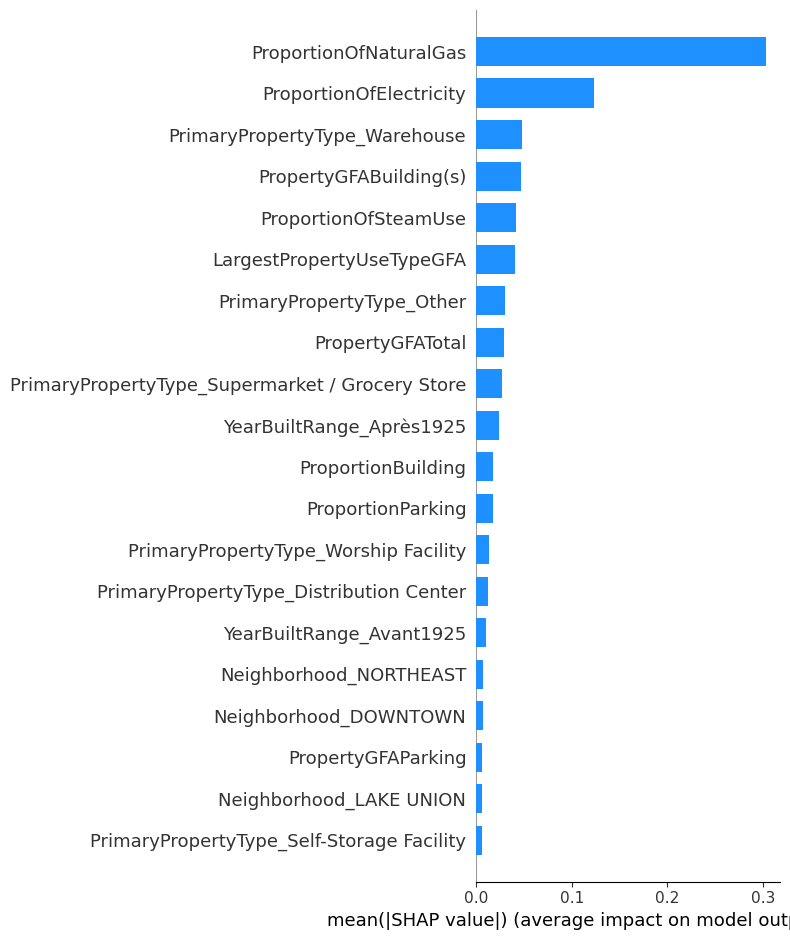

In [45]:
import shap
# Analyse de l'importance des caractéristiques avec SHAP
explainer = shap.Explainer(best_model, X_train)
shap_values = explainer(X_test, check_additivity=False)

# Affichage de l'importance des caractéristiques sous forme de barres
shap.summary_plot(shap_values.values, X_test, plot_type="bar", color="dodgerblue")

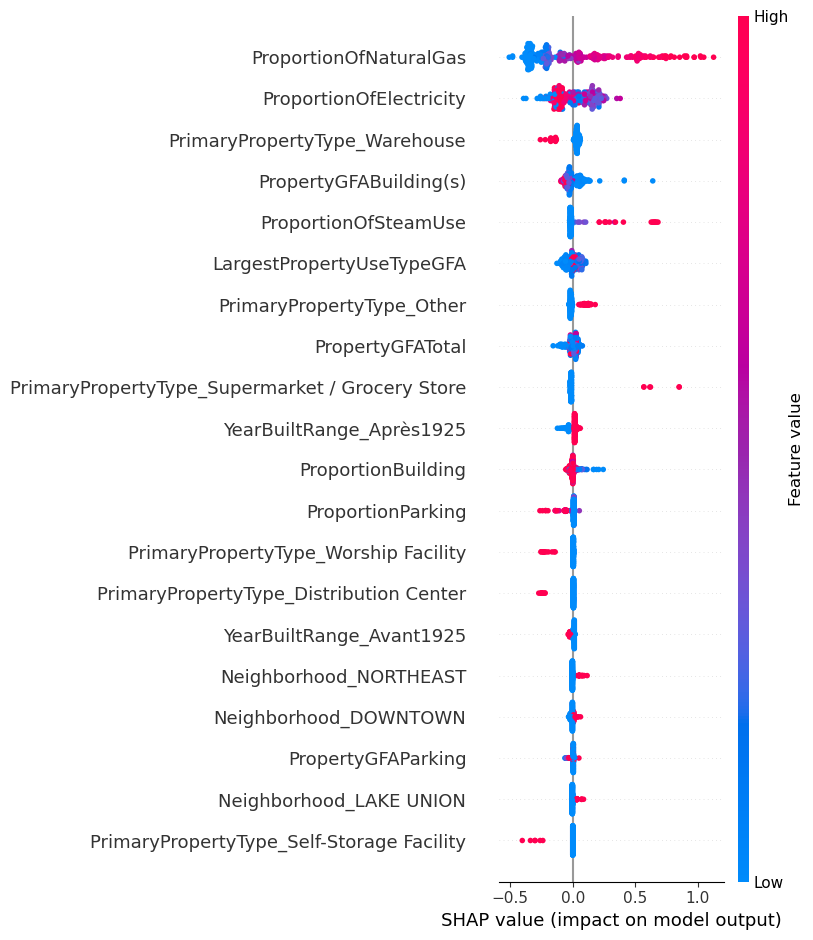

In [46]:
# Affichage des valeurs SHAP
shap.summary_plot(shap_values, X_test)

### Importance local

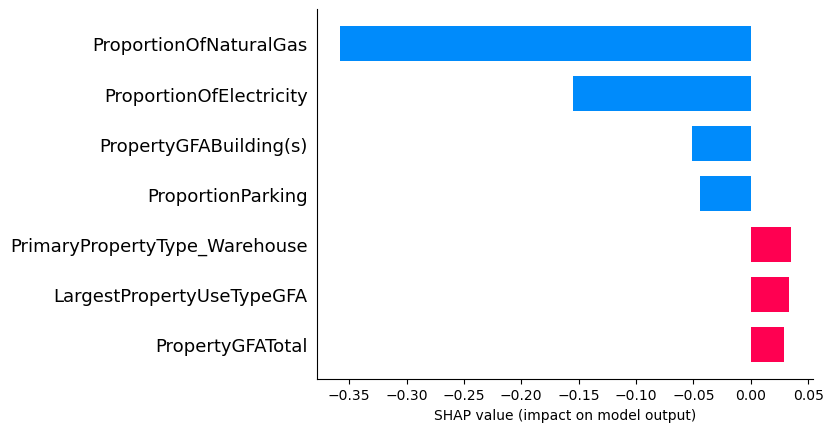

In [47]:
shap.initjs()
shap.bar_plot(
    explainer.shap_values(X_test.iloc[1].values),  # Extraire correctement les valeurs SHAP
    feature_names=X_test.columns
)

# Affichage du force plot pour la première instance de test
shap.force_plot(
    explainer.expected_value, 
    shap_values[0].values, 
    X_test.iloc[0, :], 
    feature_names=X_test.columns
)

In [48]:
#! pip install lime

In [49]:
import lime
import lime.lime_tabular
import numpy as np

# Création de l'explainer LIME
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train), 
    feature_names=X_train.columns.tolist(),
    class_names=['GHGEmissionsIntensity'],  # Nom de la variable cible
    mode='regression'
)

# Choisir une instance spécifique à expliquer (exemple : la première instance du test set)
i = 0
exp = explainer.explain_instance(
    X_test.iloc[i, :].values, 
    best_model.predict, 
    num_features=10
)

# Affichage du graphique LIME
exp.show_in_notebook()

# Evaluation de l'importance de Energy Star Score

In [50]:
df2 = df2.dropna(subset=['ENERGYSTARScore'])

In [51]:
df3 = df2.copy()

In [52]:
df3 = df3.drop(["ENERGYSTARScore"], axis=1)

## Modèle avec EnergyStarScore

In [53]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 976 entries, 0 to 1502
Data columns (total 50 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   NumberofBuildings                                976 non-null    int64  
 1   PropertyGFATotal                                 976 non-null    int64  
 2   PropertyGFAParking                               976 non-null    int64  
 3   PropertyGFABuilding(s)                           976 non-null    int64  
 4   LargestPropertyUseTypeGFA                        976 non-null    float64
 5   ENERGYSTARScore                                  976 non-null    float64
 6   ProportionOfSteamUse                             976 non-null    float64
 7   ProportionOfElectricity                          976 non-null    float64
 8   ProportionOfNaturalGas                           976 non-null    float64
 9   ProportionParking              

In [54]:
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import GradientBoostingRegressor
import numpy as np
import pandas as pd
import time

# Séparation des variables explicatives et cible
X = df2.drop(columns=['GHGEmissionsIntensity'])
y = df2['GHGEmissionsIntensity']

# Transformation logarithmique de la variable cible si activée
y_log = np.log1p(y) if logarithmiqueTrans else y

# Séparation en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y_log, test_size=0.2, random_state=42)

# Standardisation des variables explicatives si activée
if standardize:
    scaler = StandardScaler()
    X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
    X_test = pd.DataFrame(scaler.transform(X_test), columns=X.columns)

# Initialisation du modèle Gradient Boosting
gb_model = GradientBoostingRegressor(random_state=42)

# Définir la grille des hyperparamètres pour la validation croisée
param_grid = {
    'n_estimators': [100],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7, 10, 20],
    'subsample': [0.8]
}

# Appeler la fonction pour entraîner et évaluer
best_model = train_and_evaluate(
    X_train, 
    X_test, 
    y_train, 
    y_test, 
    "Standardisation" if standardize else "Sans Standardisation"
)


Entraînement Standardisation :
Temps d'entraînement (fit) : 21.4731 secondes
Temps de prédiction : 0.0019 secondes
Meilleurs hyperparamètres : {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}

Mesure sur test
R2 : 0.8119
RMSE : 0.6554
MAE : 0.3382

Scores moyens pour chaque mesure dans la validation croisée :
Moyenne des scores R² : 0.7485
Moyenne des scores RMSE : 0.0631
Moyenne des scores MAE : 0.1719


## Modèle sans EnergyStarScore

In [55]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 976 entries, 0 to 1502
Data columns (total 49 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   NumberofBuildings                                976 non-null    int64  
 1   PropertyGFATotal                                 976 non-null    int64  
 2   PropertyGFAParking                               976 non-null    int64  
 3   PropertyGFABuilding(s)                           976 non-null    int64  
 4   LargestPropertyUseTypeGFA                        976 non-null    float64
 5   ProportionOfSteamUse                             976 non-null    float64
 6   ProportionOfElectricity                          976 non-null    float64
 7   ProportionOfNaturalGas                           976 non-null    float64
 8   ProportionParking                                976 non-null    float64
 9   ProportionBuilding             

In [56]:
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import GradientBoostingRegressor
import numpy as np
import pandas as pd
import time

# Séparation des variables explicatives et cible
X = df3.drop(columns=['GHGEmissionsIntensity'])
y = df3['GHGEmissionsIntensity']

# Transformation logarithmique de la variable cible si activée
y_log = np.log1p(y) if logarithmiqueTrans else y

# Séparation en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y_log, test_size=0.2, random_state=42)

# Standardisation des variables explicatives si activée
if standardize:
    scaler = StandardScaler()
    X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
    X_test = pd.DataFrame(scaler.transform(X_test), columns=X.columns)

# Initialisation du modèle Gradient Boosting
gb_model = GradientBoostingRegressor(random_state=42)

# Définir la grille des hyperparamètres pour la validation croisée
param_grid = {
    'n_estimators': [100],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7, 10, 20],
    'subsample': [0.8]
}

# Appeler la fonction pour entraîner et évaluer
best_model = train_and_evaluate(
    X_train, 
    X_test, 
    y_train, 
    y_test, 
    "Standardisation" if standardize else "Sans Standardisation"
)


Entraînement Standardisation :
Temps d'entraînement (fit) : 18.7773 secondes
Temps de prédiction : 0.0030 secondes
Meilleurs hyperparamètres : {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}

Mesure sur test
R2 : 0.7213
RMSE : 0.7977
MAE : 0.4503

Scores moyens pour chaque mesure dans la validation croisée :
Moyenne des scores R² : 0.6616
Moyenne des scores RMSE : 0.0850
Moyenne des scores MAE : 0.2075


In [57]:
# Enregistrer le DataFrame dans un fichier CSV
#df1.to_csv('building.csv', index=False)